In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# testing_data = pd.read_csv('data/banking/new_test.csv')
data = pd.read_csv('data/banking/new_train.csv')
data.head()
# training_data.info()
# testing_data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
0,49,blue-collar,married,basic.9y,unknown,no,no,cellular,nov,wed,227,4,999,0,nonexistent,no
1,37,entrepreneur,married,university.degree,no,no,no,telephone,nov,wed,202,2,999,1,failure,no
2,78,retired,married,basic.4y,no,no,no,cellular,jul,mon,1148,1,999,0,nonexistent,yes
3,36,admin.,married,university.degree,no,yes,no,telephone,may,mon,120,2,999,0,nonexistent,no
4,59,retired,divorced,university.degree,no,no,no,cellular,jun,tue,368,2,999,0,nonexistent,no


In [3]:
data.describe(include='number')

,age,duration,campaign,pdays,previous
count,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000
mean,40.014112,258.127466,2.560607,962.052413,0.174719
std,10.403636,258.975917,2.752326,187.951096,0.499025
min,17.000000,0.000000,1.000000,0.000000,0.000000
25%,32.000000,103.000000,1.000000,999.000000,0.000000
50%,38.000000,180.000000,2.000000,999.000000,0.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000
max,98.000000,4918.000000,56.000000,999.000000,7.000000


In [4]:
data = data[data['duration']> 1000]
data = data[data['campaign']< 10]
data = data[data['previous']< 2]
data = data[data['age'] < 70]
data = data.drop(['pdays','default'],axis=1)

In [5]:
data.select_dtypes(include=['object']).value_counts
data.describe(include=['object'])


,job,marital,education,housing,loan,contact,month,day_of_week,poutcome,y
count,711,711,711,711,711,711,711,711,711,711
unique,12,4,8,3,3,2,10,5,3,2
top,blue-collar,married,university.degree,yes,no,cellular,may,thu,nonexistent,yes
freq,189,432,208,356,565,467,210,161,645,411


In [6]:
data[data['default']=='yes']

KeyError: 'default'

<Axes: >

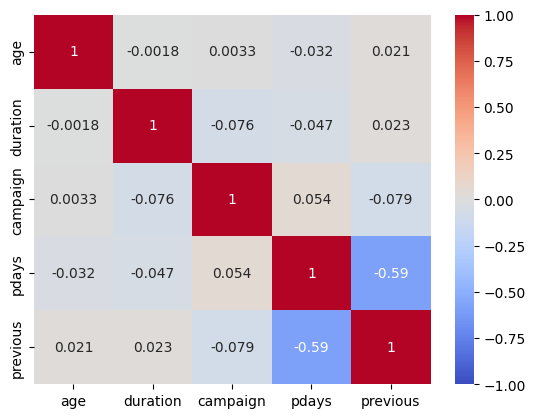

In [ ]:

sns.heatmap(data.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', vmin=-1)

In [ ]:
# testing_data.head()
data.head()
x = pd.get_dummies(data.drop(['y'], axis=1))
y = data['y']
# x_test = pd.get_dummies(testing_data)

In [ ]:

from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, cross_val_predict

In [ ]:
def perform_model(model_type):
    pred = cross_val_predict(model_type, x, y, cv=3)
    # print("Cross-validation score average:", np.mean(results['test_score']))

    return pred

In [ ]:
from sklearn.linear_model import LogisticRegression
logreg_pred = perform_model(LogisticRegression(max_iter=100000))

In [ ]:
from sklearn.linear_model import RidgeClassifier
ridge_pred = perform_model(RidgeClassifier())

In [ ]:
from sklearn.svm import SVC
svc_pred = perform_model(SVC())

In [ ]:
from sklearn.linear_model import SGDClassifier
sgd_pred = perform_model(SGDClassifier())

In [ ]:
from sklearn.naive_bayes import GaussianNB
gnb_pred = perform_model(GaussianNB())

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtc_pred = perform_model(DecisionTreeClassifier())

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rfc50_pred = perform_model(RandomForestClassifier(n_estimators=50))
rfc100_pred = perform_model(RandomForestClassifier(n_estimators=100))

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
kn5_pred = perform_model(KNeighborsClassifier(n_neighbors=5))
kn10_pred = perform_model(KNeighborsClassifier(n_neighbors=10))

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay


Model Type:  logreg
              precision    recall  f1-score   support

          no       0.92      0.98      0.95     29238
         yes       0.65      0.35      0.46      3712

    accuracy                           0.91     32950
   macro avg       0.79      0.66      0.70     32950
weighted avg       0.89      0.91      0.89     32950



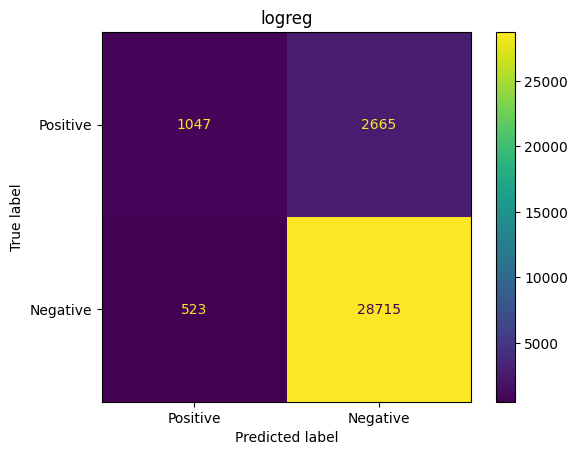




Model Type:  ridge
              precision    recall  f1-score   support

          no       0.92      0.98      0.95     29238
         yes       0.67      0.28      0.40      3712

    accuracy                           0.90     32950
   macro avg       0.79      0.63      0.67     32950
weighted avg       0.89      0.90      0.89     32950



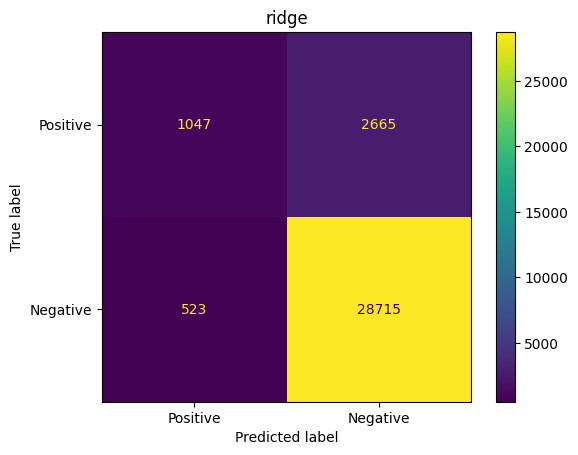




Model Type:  svc
              precision    recall  f1-score   support

          no       0.92      0.98      0.95     29238
         yes       0.64      0.29      0.40      3712

    accuracy                           0.90     32950
   macro avg       0.78      0.63      0.67     32950
weighted avg       0.88      0.90      0.88     32950



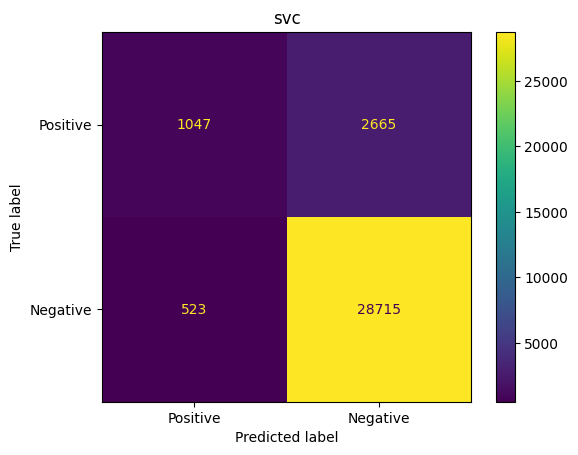




Model Type:  sgd
              precision    recall  f1-score   support

          no       0.94      0.87      0.90     29238
         yes       0.35      0.57      0.43      3712

    accuracy                           0.83     32950
   macro avg       0.65      0.72      0.67     32950
weighted avg       0.87      0.83      0.85     32950



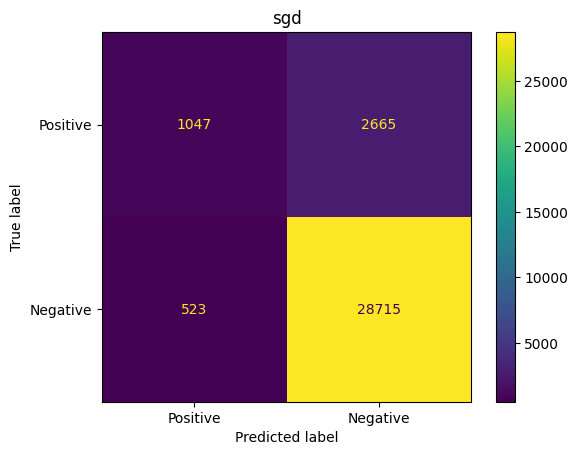




Model Type:  gnb
              precision    recall  f1-score   support

          no       0.93      0.92      0.93     29238
         yes       0.43      0.47      0.45      3712

    accuracy                           0.87     32950
   macro avg       0.68      0.70      0.69     32950
weighted avg       0.88      0.87      0.87     32950



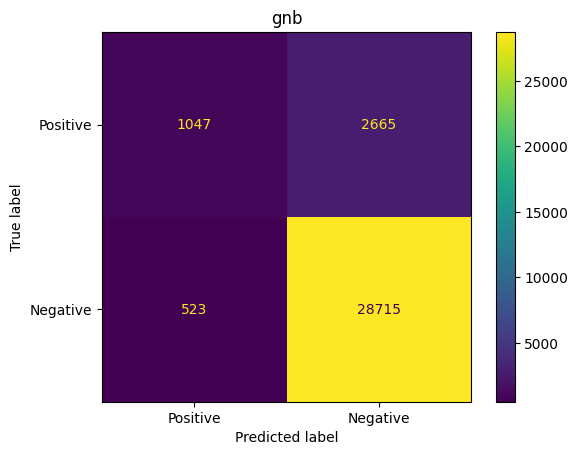




Model Type:  dtc
              precision    recall  f1-score   support

          no       0.93      0.93      0.93     29238
         yes       0.44      0.46      0.45      3712

    accuracy                           0.87     32950
   macro avg       0.68      0.69      0.69     32950
weighted avg       0.88      0.87      0.87     32950



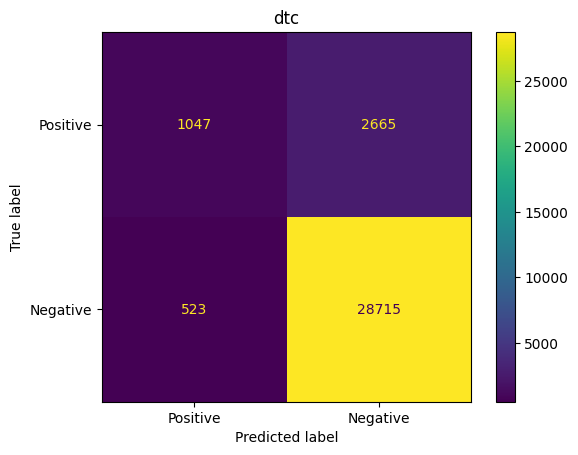




Model Type:  rfc50
              precision    recall  f1-score   support

          no       0.93      0.97      0.95     29238
         yes       0.64      0.38      0.48      3712

    accuracy                           0.91     32950
   macro avg       0.78      0.68      0.71     32950
weighted avg       0.89      0.91      0.90     32950



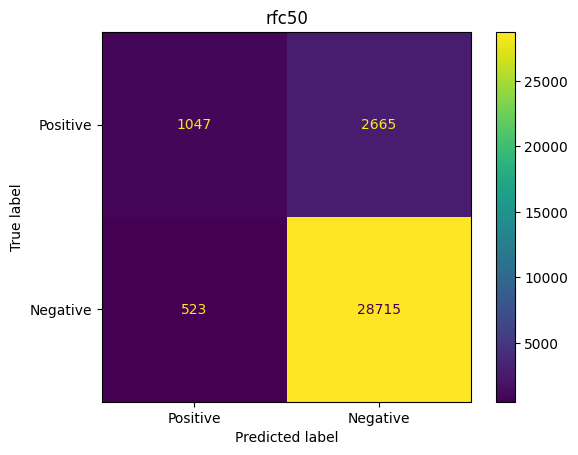




Model Type:  rfc100
              precision    recall  f1-score   support

          no       0.93      0.97      0.95     29238
         yes       0.64      0.38      0.48      3712

    accuracy                           0.91     32950
   macro avg       0.78      0.68      0.71     32950
weighted avg       0.89      0.91      0.90     32950



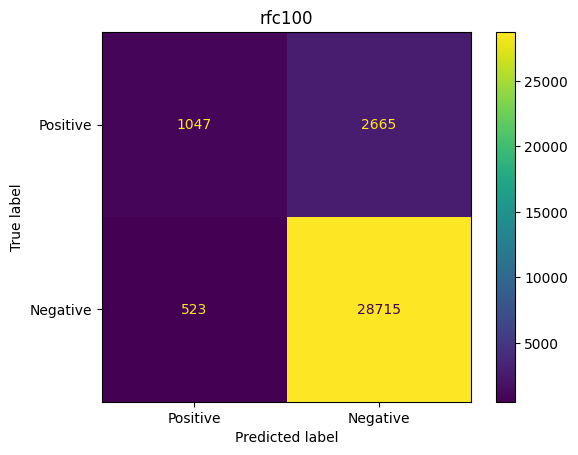




Model Type:  kn5
              precision    recall  f1-score   support

          no       0.92      0.97      0.94     29238
         yes       0.58      0.37      0.45      3712

    accuracy                           0.90     32950
   macro avg       0.75      0.67      0.70     32950
weighted avg       0.88      0.90      0.89     32950



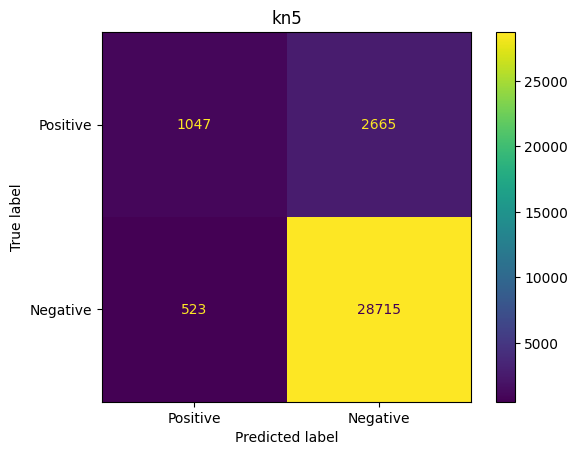




Model Type:  kn10
              precision    recall  f1-score   support

          no       0.92      0.98      0.95     29238
         yes       0.64      0.32      0.42      3712

    accuracy                           0.90     32950
   macro avg       0.78      0.65      0.69     32950
weighted avg       0.89      0.90      0.89     32950



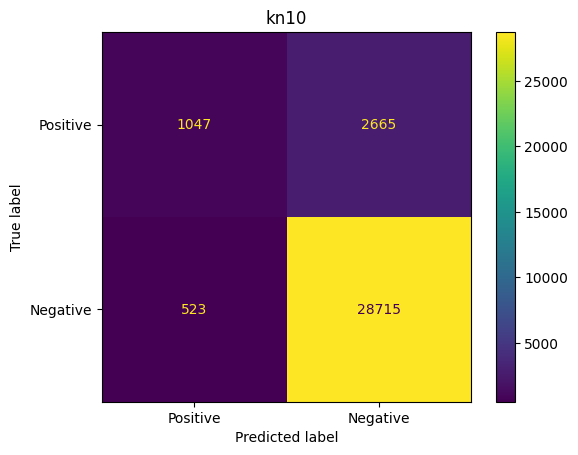

In [ ]:
predictions = [logreg_pred, ridge_pred, svc_pred, sgd_pred, gnb_pred, dtc_pred, rfc50_pred, rfc100_pred, kn5_pred, kn10_pred]
predictions_names = ['logreg', 'ridge', 'svc', 'sgd', 'gnb', 'dtc', 'rfc50', 'rfc100', 'kn5', 'kn10']
accuracy_list = [0] * len(predictions)
for i in range(len(predictions)):
    pred = predictions[i]
    accuracy_list[i] = accuracy_score(y, pred)
    print('Model Type: ', predictions_names[i])
    print(classification_report(y, pred))
    ConfusionMatrixDisplay(np.flip(confusion_matrix(y, ridge_pred)),display_labels=['Positive','Negative']).plot()
    plt.title(predictions_names[i])
    plt.show()
    print('\n\n')

In [ ]:
accuracy_list

[0.9059180576631259,
 0.9032473444613051,
 0.9012139605462822,
 0.8343247344461305,
 0.869742033383915,
 0.8726251896813354,
 0.9062215477996965,
 0.9058270106221548,
 0.8982397572078907,
 0.9029742033383915]

[0.9059180576631259,
 0.9032473444613051,
 0.9012139605462822,
 0.8343247344461305,
 0.869742033383915,
 0.8726251896813354,
 0.9062215477996965,
 0.9058270106221548,
 0.8982397572078907,
 0.9029742033383915]

In [ ]:
# ridge_pred
# print(classification_report(y, ridge_pred))
# confusion_matrix(y, ridge_pred)
# ConfusionMatrixDisplay(confusion_matrix(y, ridge_pred)).plot()

In [ ]:


# confusion_matrix(y, ridge_pred, normalize='all')